<a href="https://colab.research.google.com/github/gamewithdata11/C2N/blob/main/Diabetes_Disease_Prediction_all_classification_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objective
* Build a machine learning model to predict whether a patient has diabetes based on diagnostic measurements.
# Tools used
* python
* pandas,numpy
* matplotlib,seaborn
* scikitlearn
* streamlit

# Data collection and understanding
* For this project, we will use the Pima Indians Diabetes Dataset, a well-known dataset in machine learning for binary classification
* Number of instance is 768
* Number of Attributes
* 8 medical predictors
* one target variable -- 1 for diabetes and 0 for non-diabetes

# Attributes:

* Pregnancies: Number of times pregnant

* Glucose: Plasma glucose concentration (2 hours in an oral glucose tolerance test)

* BloodPressure: Diastolic blood pressure (mm Hg)

* SkinThickness: Triceps skin fold thickness (mm)

* Insulin: 2-Hour serum insulin (mu U/ml)

* BMI: Body mass index (weight in kg/(height in m)^2)

* DiabetesPedigreeFunction: Diabetes pedigree function

* Age: Age (years)

* Outcome: Class variable (0 or 1)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
pd.set_option("display.max_rows",None)

In [ ]:
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [ ]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Data cleaning

In [ ]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
zero_col=['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin','BMI', 'DiabetesPedigreeFunction', 'Age']
df[zero_col] = df[zero_col].replace(0, np.nan)

In [ ]:
# check missing values
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
for col in zero_col:
    df[col].fillna(df[col].median(),inplace=True)

In [ ]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# Exploratory data analysis
# univariate analysis, bivariant analysis, multivariate analysis

In [ ]:
diabetes_by_pre=df.groupby('Pregnancies')[['Outcome']].mean().reset_index()
diabetes_by_pre

,Pregnancies,Outcome
0,0,0.342342
1,1,0.214815
2,2,0.184466
3,3,0.360000
4,4,0.338235
5,5,0.368421
6,6,0.320000
7,7,0.555556
8,8,0.578947
9,9,0.642857


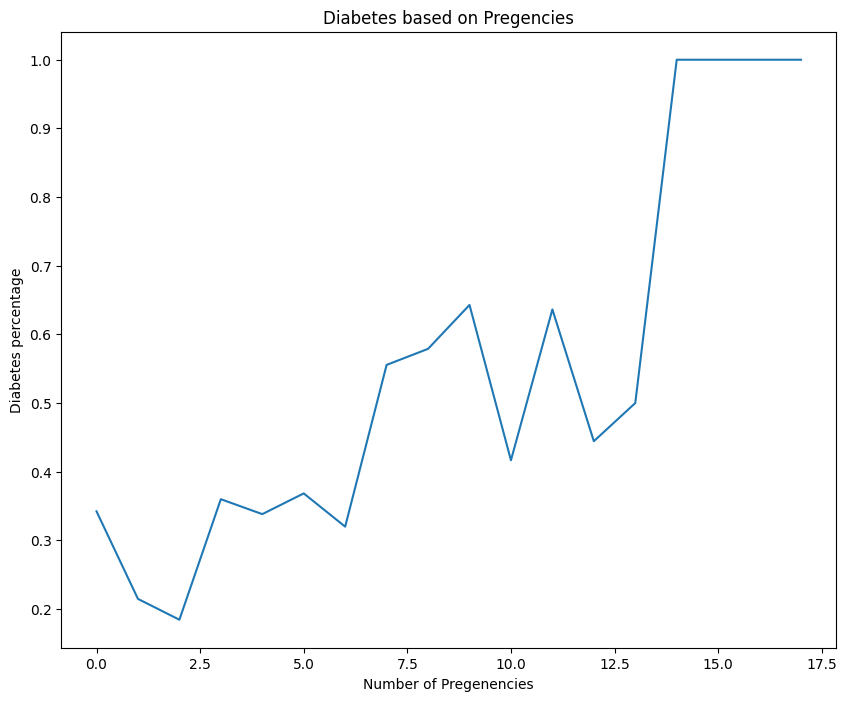

In [ ]:
plt.figure(figsize=(10,8))
plt.plot(diabetes_by_pre['Pregnancies'],diabetes_by_pre['Outcome'])
plt.title('Diabetes based on Pregencies')
plt.xlabel('Number of Pregenencies')
plt.ylabel("Diabetes percentage")
plt.show()

In [ ]:
# check relation with increase glucose level and diabetes
# we have to create bins or groups so that we can gix some specific group other wise it will messy

In [ ]:
bins=[0,80,100,120,140,160,180,200,300]
labels=['<80','80-100','100-120','120-140','140-160','160-180','180-200','>200']

* pd.cut() is a Pandas function used to split continuous data into intervals (bins).

* It helps when you want to group numeric values into categories.

In [ ]:
# create a new column so that we can categoreis glucose levels in interval or group instead of continous
df['GlucoseRange'] =pd.cut(df['Glucose'],bins=bins,labels=labels)


In [ ]:
# Grouby GlucoseRange and get the mean value in range
diab_by_glu=df.groupby('GlucoseRange')[['Outcome']].mean().reset_index()
diab_by_glu

,GlucoseRange,Outcome
0,<80,0.047619
1,80-100,0.095808
2,100-120,0.261905
3,120-140,0.401274
4,140-160,0.538462
5,160-180,0.800000
6,180-200,0.853659
7,>200,NaN


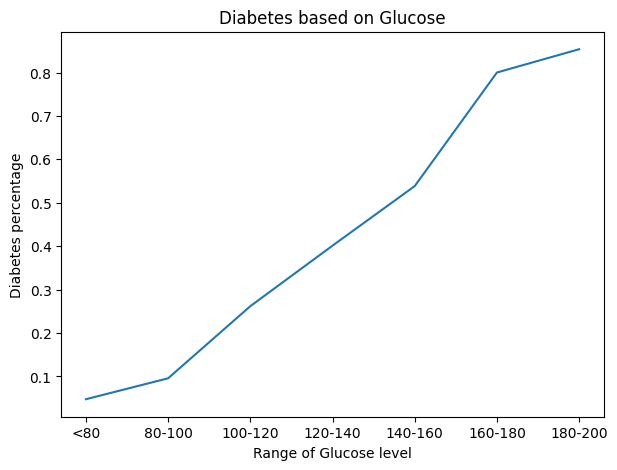

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(diab_by_glu['GlucoseRange'],diab_by_glu['Outcome'])
plt.title('Diabetes based on Glucose')
plt.xlabel('Range of Glucose level')
plt.ylabel("Diabetes percentage")
plt.show()

<Figure size 1000x600 with 0 Axes>

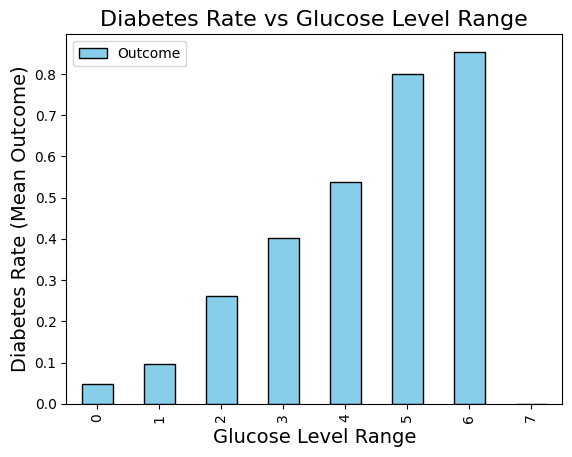

In [ ]:
# Plot
plt.figure(figsize=(10,6))
diab_by_glu.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Diabetes Rate vs Glucose Level Range', fontsize=16)
plt.xlabel('Glucose Level Range', fontsize=14)
plt.ylabel('Diabetes Rate (Mean Outcome)', fontsize=14)
plt.show()

In [ ]:
df.groupby('GlucoseRange')['Outcome'].count()

GlucoseRange
<80         42
80-100     167
100-120    210
120-140    157
140-160     91
160-180     60
180-200     41
>200         0
Name: Outcome, dtype: int64

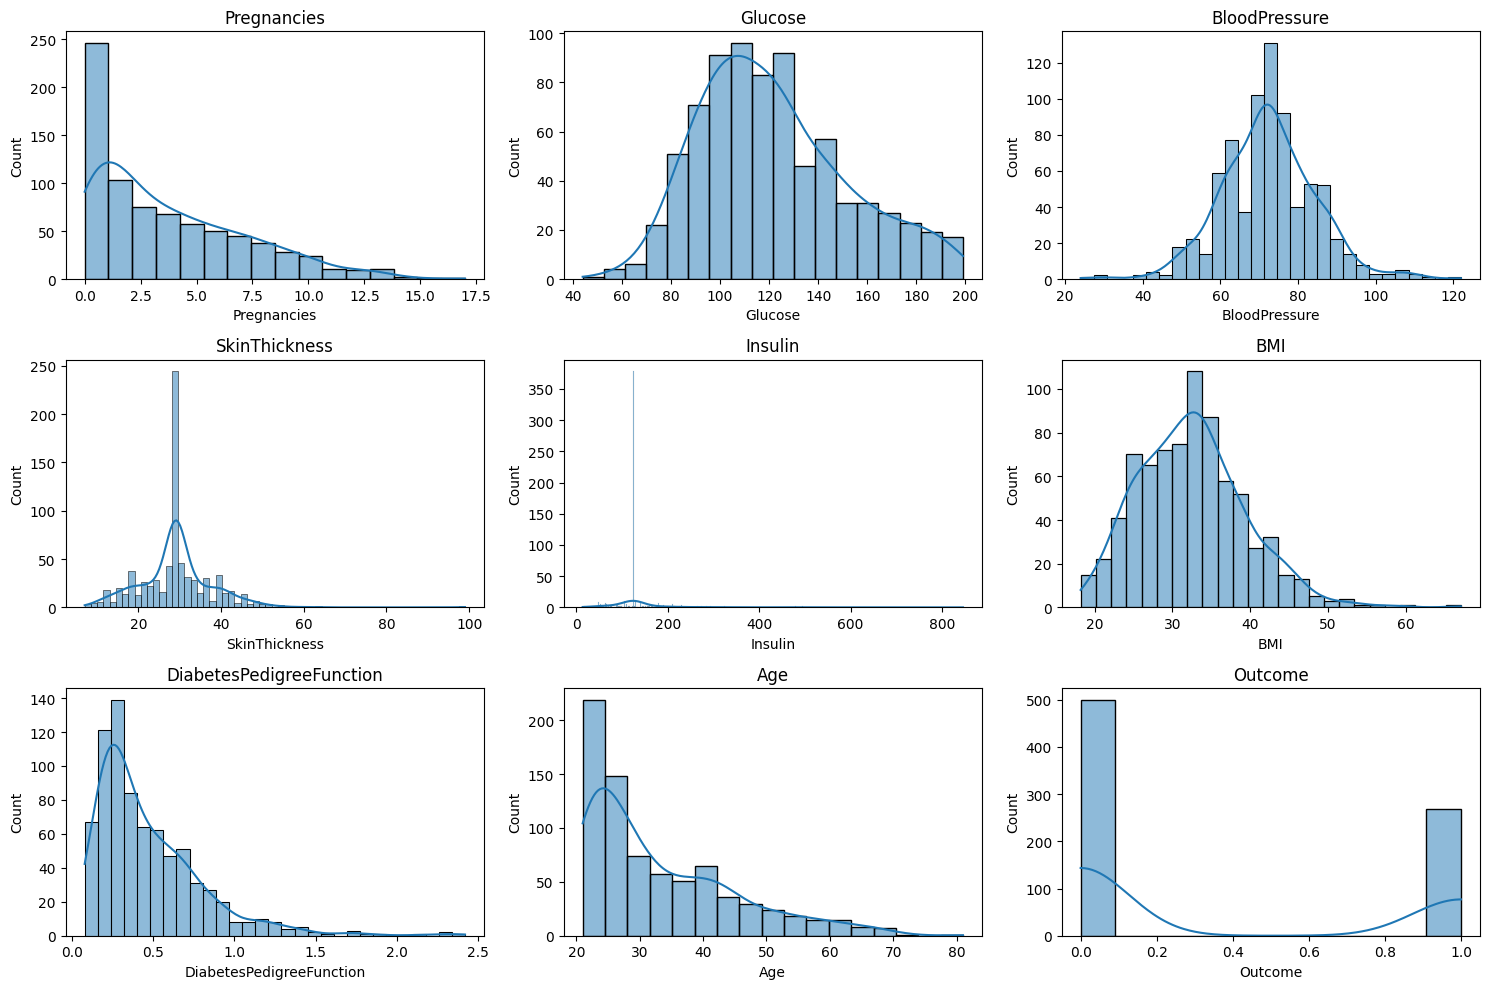

In [ ]:
# plot for univariate analysis
plt.figure(figsize=(15,10))
for i,col in enumerate(df.columns[:-1]):
    plt.subplot(3,3,i+1)
    sns.histplot(df[col],kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

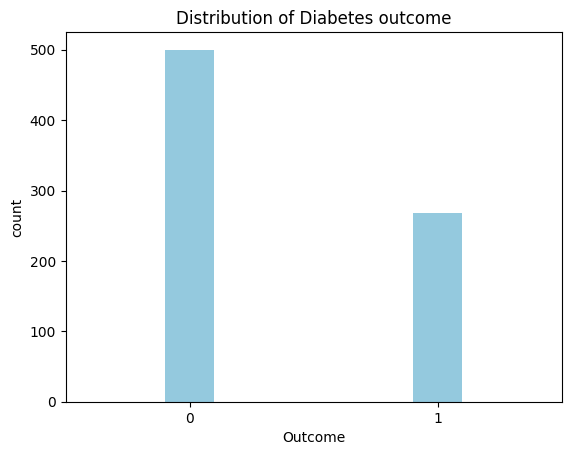

In [ ]:
# Target variable distribution
sns.countplot(x='Outcome',data=df,width=0.2,color='skyblue')
plt.title("Distribution of Diabetes outcome")
plt.show()

In [ ]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

# Bivariate Analysis

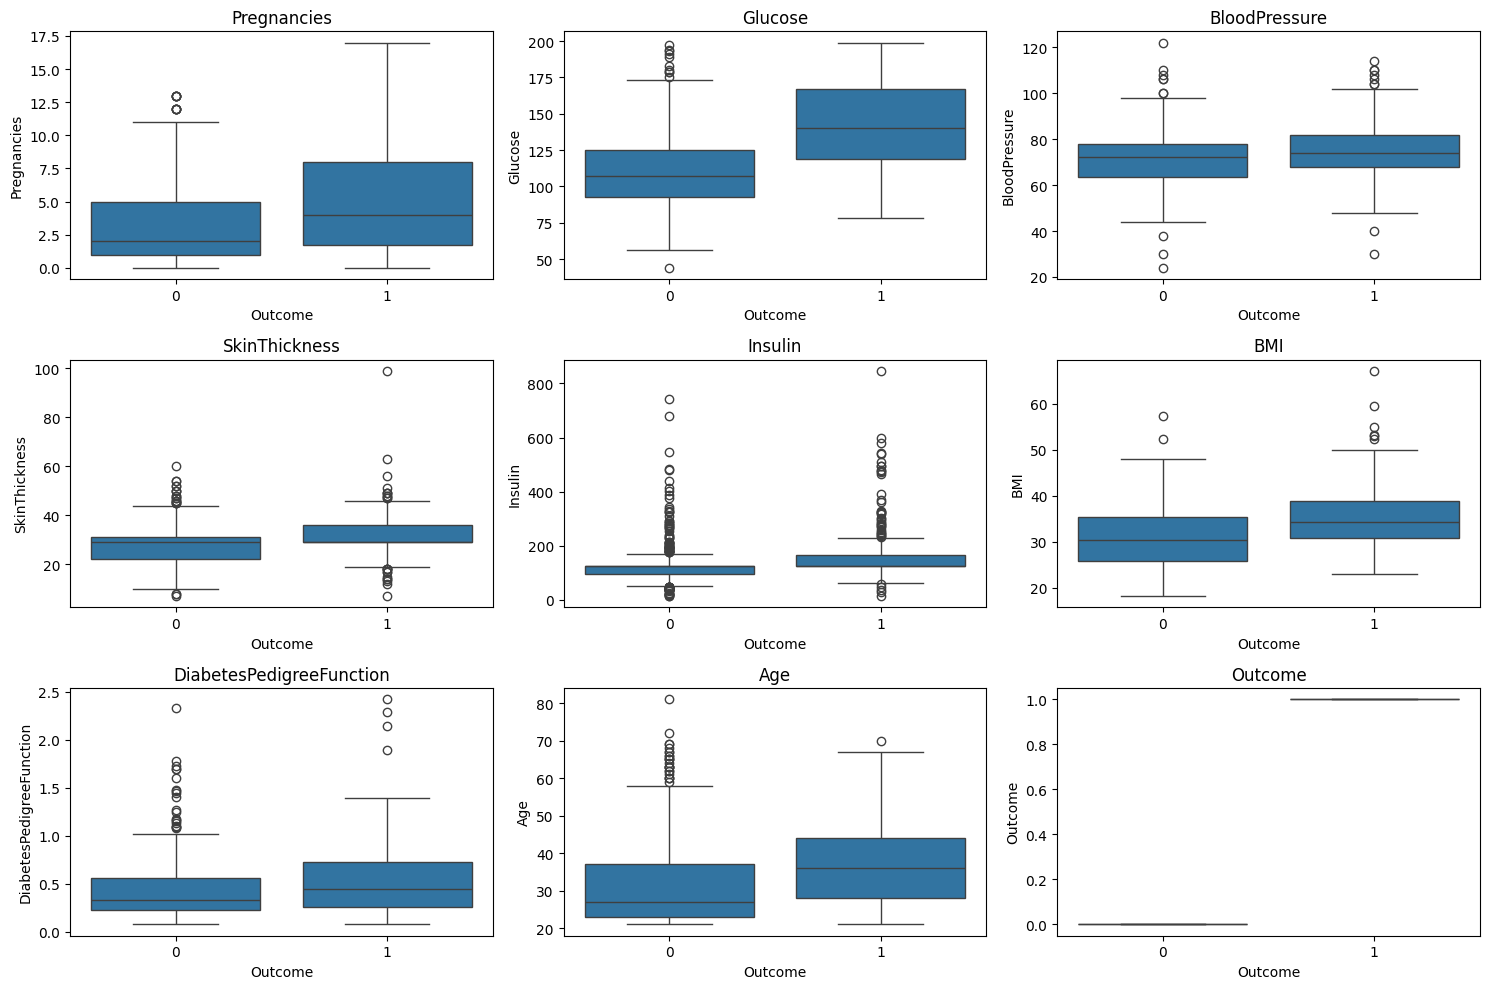

In [ ]:
# compare feature with outcome
plt.figure(figsize=(15,10))
for i,col in enumerate(df.columns[:-1]):
    plt.subplot(3,3,i+1)
    sns.boxplot(x='Outcome',y=col,data=df)
    plt.title(col)
plt.tight_layout()
plt.show()

In [ ]:
# Feature Engineering if needed
df['AgeGroup']=pd.cut(df['Age'],bins=[20,30,40,50,60,100],labels=['20-29','30-39','40-49','50-59','>60'])
df['AgeGroup'].value_counts()

AgeGroup
20-29    417
30-39    157
40-49    113
50-59     54
>60       27
Name: count, dtype: int64

In [ ]:
# Seperate the feature and target
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'GlucoseRange',
       'AgeGroup'],
      dtype='object')

In [ ]:
corr_matrix=df[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']].corr()

In [ ]:
corr_matrix

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Pregnancies,1.000000,0.128213,0.208615,0.081770,0.025047,0.021559,-0.033523,0.544341
Glucose,0.128213,1.000000,0.218937,0.192615,0.419451,0.231049,0.137327,0.266909
BloodPressure,0.208615,0.218937,1.000000,0.191892,0.045363,0.281257,-0.002378,0.324915
SkinThickness,0.081770,0.192615,0.191892,1.000000,0.155610,0.543205,0.102188,0.126107
Insulin,0.025047,0.419451,0.045363,0.155610,1.000000,0.180241,0.126503,0.097101
BMI,0.021559,0.231049,0.281257,0.543205,0.180241,1.000000,0.153438,0.025597
DiabetesPedigreeFunction,-0.033523,0.137327,-0.002378,0.102188,0.126503,0.153438,1.000000,0.033561
Age,0.544341,0.266909,0.324915,0.126107,0.097101,0.025597,0.033561,1.000000


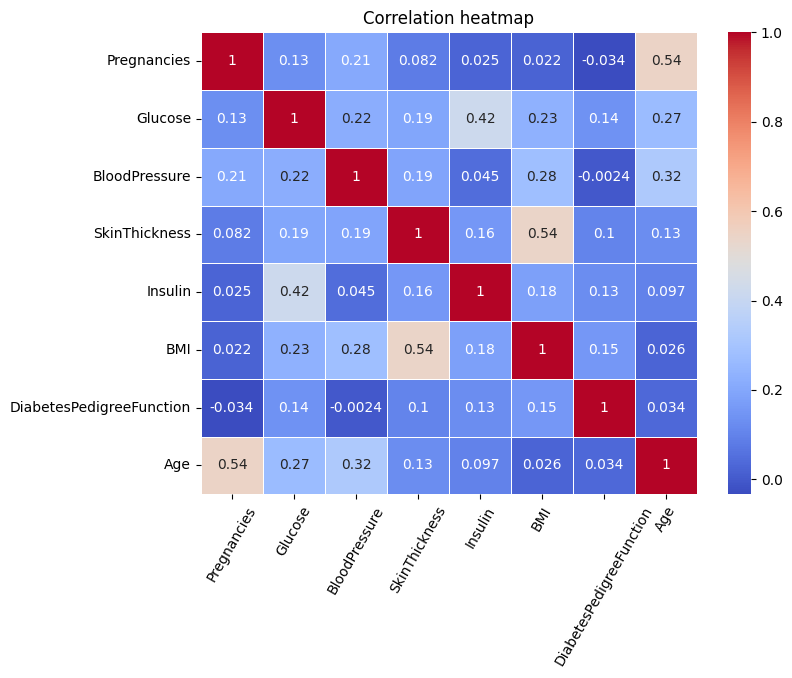

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',linewidths=0.5)
plt.title("Correlation heatmap")
plt.xticks(rotation=60)
plt.show()

# ![image.png](attachment:180e79a1-67e2-4eaa-93ea-71c8cf32a637.png)

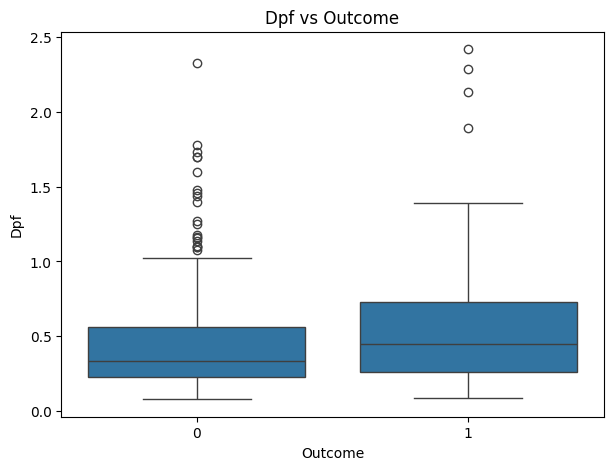

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(y='DiabetesPedigreeFunction',x='Outcome',data=df)
plt.title("Dpf vs Outcome")
plt.ylabel("Dpf")
plt.xlabel("Outcome")
plt.show()

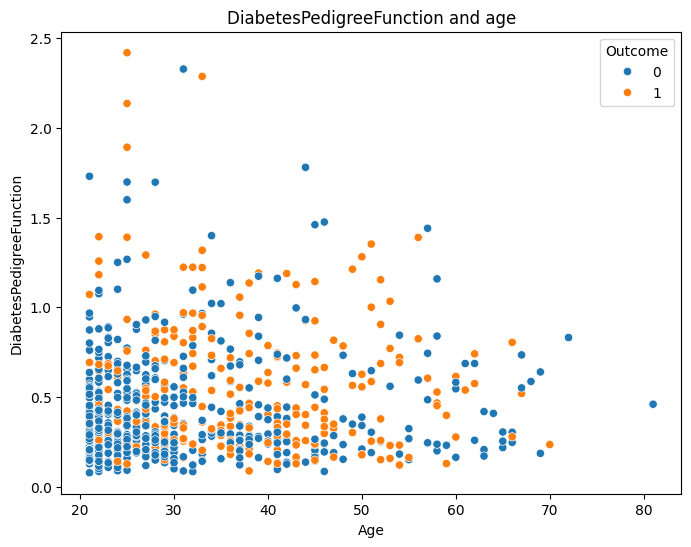

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Age',y='DiabetesPedigreeFunction',hue='Outcome',data=df)
plt.title("DiabetesPedigreeFunction and age")
plt.show()

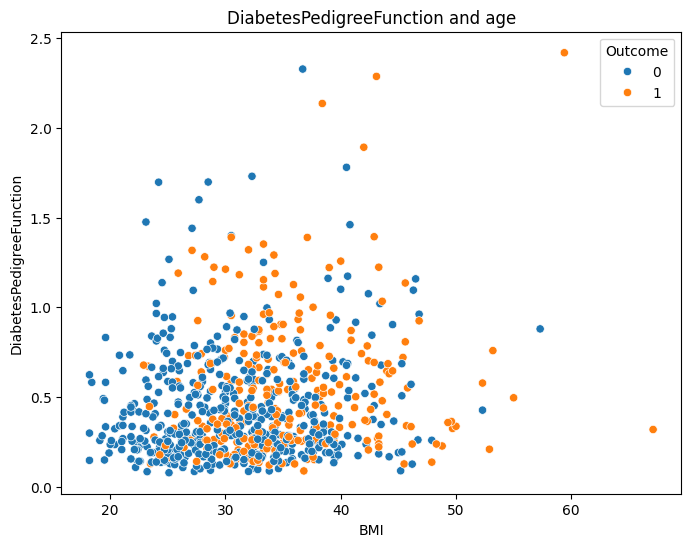

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='BMI',y='DiabetesPedigreeFunction',hue='Outcome',data=df)
plt.title("DiabetesPedigreeFunction and age")
plt.show()

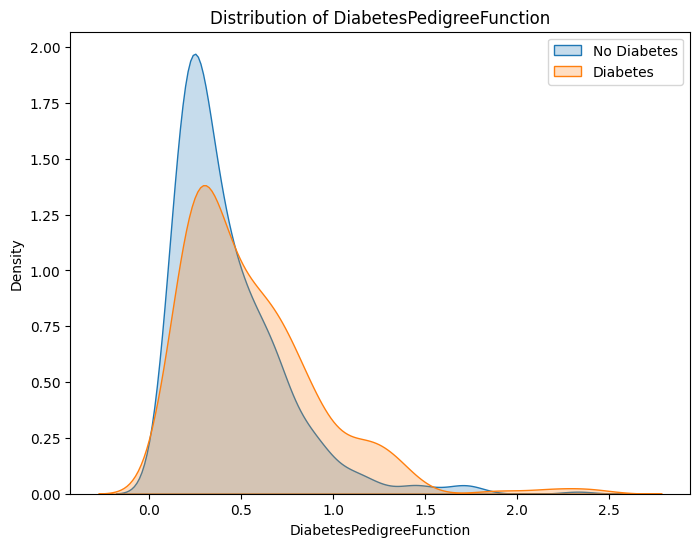

In [ ]:
plt.figure(figsize=(8,6))
sns.kdeplot(data=df[df['Outcome']==0]['DiabetesPedigreeFunction'], label='No Diabetes', shade=True)
sns.kdeplot(data=df[df['Outcome']==1]['DiabetesPedigreeFunction'], label='Diabetes', shade=True)
plt.title('Distribution of DiabetesPedigreeFunction')
plt.xlabel('DiabetesPedigreeFunction')
plt.legend()
plt.show()

In [ ]:
# feature selection
X=df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness','Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']]
y=df['Outcome']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,classification_report

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(X,y)

RandomForestClassifier()

In [ ]:
features=X.columns
importances=rf.feature_importances_  # Random Forest calculates importance score for each feature (how much each feature helps to predict).
indices=np.argsort(importances)  # Sorting features based on their importance (lowest to highest).

In [ ]:
print(importances)
print(indices)

[0.08330435 0.24478495 0.08644247 0.06851662 0.08782242 0.1709034
 0.1263627  0.13186308]
[3 0 2 4 6 7 5 1]


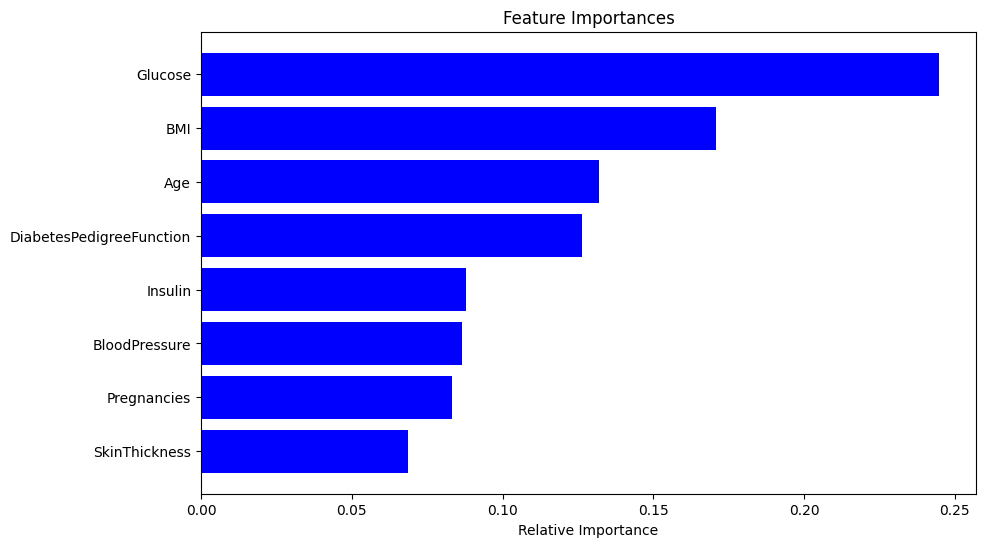

In [ ]:
plt.figure(figsize=(10, 6))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [ ]:
# Select top features (example: top 5)
selected_features = [features[i] for i in indices[-5:]]
X = X[selected_features]

In [ ]:
# split data into train test and split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
# Standaridize feature
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

# Model Building
* Logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(X_train,y_train)


LogisticRegression()

In [ ]:
y_predict_lr=lr.predict(X_test)
y_predict_lr

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [ ]:
print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_test, y_predict_lr))
print()
print("Confusion Matrix:\n", confusion_matrix(y_test, y_predict_lr))
print()
print("Classification Report:\n", classification_report(y_test, y_predict_lr))

Logistic Regression:
Accuracy: 0.7662337662337663

Confusion Matrix:
 [[83 16]
 [20 35]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.84      0.82        99
           1       0.69      0.64      0.66        55

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.76      0.77      0.76       154



In [ ]:
selected_features

['Insulin', 'DiabetesPedigreeFunction', 'Age', 'BMI', 'Glucose']

In [ ]:
# suppose you want to predict a new patient
# Insulin = 125
# DpF = 0.45
# Age= 35
# BMI = 33.6
# Glucose=140

In [ ]:
# New data point
new_data = np.array([[125, 0.45, 32, 33.6, 140]])

#scale the new data using the same scaler
new_data_scaled = scaler.transform(new_data)

#Predict
prediction = lr.predict(new_data_scaled)

In [ ]:
if prediction[0] == 1:
    print("The person is predicted to have diabetes.")
else:
    print("The person is predicted NOT to have diabetes.")

The person is predicted NOT to have diabetes.


# K nearest Neighbour

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("K-Nearest Neighbors:")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))

K-Nearest Neighbors:
Accuracy: 0.7337662337662337
Confusion Matrix:
 [[78 21]
 [20 35]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.79      0.79        99
           1       0.62      0.64      0.63        55

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



# Support Vector Machine

In [ ]:
from sklearn.svm import SVC

In [ ]:
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("Support Vector Machine:")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))

Support Vector Machine:
Accuracy: 0.7337662337662337
Confusion Matrix:
 [[80 19]
 [22 33]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.81      0.80        99
           1       0.63      0.60      0.62        55

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.71       154
weighted avg       0.73      0.73      0.73       154



# Decesion Treee Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree:
Accuracy: 0.7012987012987013
Confusion Matrix:
 [[69 30]
 [16 39]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.70      0.75        99
           1       0.57      0.71      0.63        55

    accuracy                           0.70       154
   macro avg       0.69      0.70      0.69       154
weighted avg       0.72      0.70      0.71       154



# Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest:
Accuracy: 0.7402597402597403
Confusion Matrix:
 [[76 23]
 [17 38]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.77      0.79        99
           1       0.62      0.69      0.66        55

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.74      0.74       154



# XGBoost Classifier

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))

XGBoost:
Accuracy: 0.7402597402597403
Confusion Matrix:
 [[75 24]
 [16 39]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.76      0.79        99
           1       0.62      0.71      0.66        55

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.73       154
weighted avg       0.75      0.74      0.74       154



# Model comparison

In [ ]:
models = {
    'Logistic Regression': lr,
    'K-Nearest Neighbors': knn,
    'Support Vector Machine': svm,
    'Decision Tree': dt,
    'Random Forest': rf,
    'XGBoost': xgb
}

In [ ]:
from sklearn.metrics import f1_score

In [ ]:
# Evaluate all models
results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append([name, accuracy, precision, recall, f1])

In [ ]:
# Create results dataframe
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
print(results_df)

                    Model  Accuracy  Precision    Recall  F1 Score
0     Logistic Regression  0.766234   0.686275  0.636364  0.660377
1     K-Nearest Neighbors  0.733766   0.625000  0.636364  0.630631
2  Support Vector Machine  0.733766   0.634615  0.600000  0.616822
3           Decision Tree  0.701299   0.565217  0.709091  0.629032
4           Random Forest  0.740260   0.622951  0.690909  0.655172
5                 XGBoost  0.740260   0.619048  0.709091  0.661017


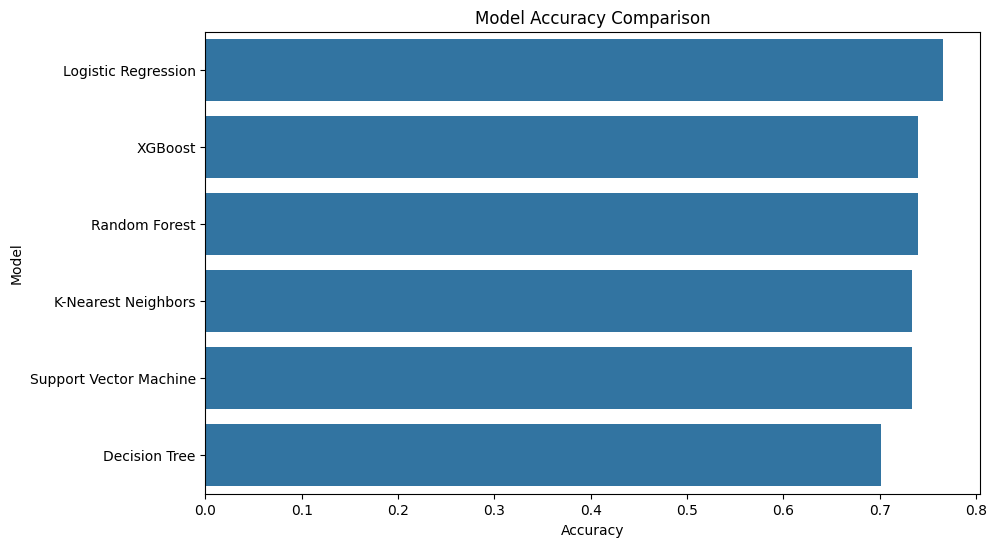

In [ ]:
# Plot model comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=results_df.sort_values('Accuracy', ascending=False))
plt.title('Model Accuracy Comparison')
plt.show()